<a href="https://colab.research.google.com/github/ThanhB18059162022/MMRec/blob/dev/preprocessing/step4_image_feature_extract/preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import shutil
from pathlib import Path
import pandas as pd

In [ ]:
# PATH = "/content/drive/MyDrive/Colab Notebooks/CTH001/MMRec/code"

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PATH = "../data/baby/2014"

In [ ]:
os.makedirs(os.path.join(PATH, "step4_image_feature_extract"), exist_ok=True)

In [ ]:
# Nén thư mục step0_clean_data/filtered_images sang step4_image_feature/filtered_images.tar.gz
shutil.make_archive(
    os.path.join(PATH, "step4_image_feature_extract", "filtered_images"),
    "gztar",
    os.path.join(PATH, "step0_clean_data", "filtered_images"),
)

'c:\\projects\\MMRec\\preprocessing\\data\\2023\\step4_image_feature_extract\\filtered_images.tar.gz'

In [ ]:
# Giải nén thư mục filtered_images.tar.gz vào step4_image_feature_extract/filtered_images
shutil.unpack_archive(
    os.path.join(PATH, "step4_image_feature_extract", "filtered_images.tar.gz"),
    os.path.join(PATH, "step4_image_feature_extract", "filtered_images"),
)

## Kiểm tra lại thư mục filtered_images xem có thiếu hình nào sau khi đã thử tải lại không

In [ ]:
df_retry_image = pd.read_parquet(os.path.join(PATH, "step0_clean_data", "df_miss_image.parquet"))

In [ ]:
df_meta_with_image = pd.read_parquet(os.path.join(PATH, "step0_clean_data", "df_meta.with_image.parquet"))

In [ ]:
# Đọc lại thư mục filtered_images và kiểm tra số hình đã copy
filtered_images_dir = Path(PATH) / "step0_clean_data" / "filtered_images"
if filtered_images_dir.exists():
    image_paths = [p for p in filtered_images_dir.rglob("*") if p.is_file()]
    total_images = len(image_paths)
    print(f"✅ Tổng file hình trong filtered_images: {total_images}")

    if "asin" in df_meta_with_image.columns:
        copied_asins = {p.stem for p in image_paths}
        asin_in_df = df_meta_with_image["asin"].dropna().astype(str).str.strip()
        total_asins_in_df = asin_in_df.nunique()
        copied_asins_count = len(copied_asins)
        missing_asins = sorted(set(asin_in_df) - copied_asins)

        print(f"ℹ️ Unique ASIN trong df: {total_asins_in_df}")
        print(f"ℹ️ Unique ASIN đã copy vào filtered_images: {copied_asins_count}")
        print(f"ℹ️ ASIN trong df chưa có file trong filtered_images: {len(missing_asins)}")
        if missing_asins:
            print("Các ASIN thiếu (max 50):")
            print(missing_asins[:50])
else:
    print(f"⚠️ Thư mục filtered_images không tồn tại: {filtered_images_dir}")

⚠️ Thư mục filtered_images không tồn tại: ..\data\baby\2014\step0_clean_data\filtered_images


In [ ]:
missing_asins

['B00005QI1H',
 'B0017WEH1S',
 'B0018CJ7G2',
 'B00192H1KA',
 'B004AAIQ1G',
 'B0092KKTQ4',
 'B009WUPGQC',
 'B00BX8RRJA',
 'B00OPZR8L0',
 'B079659G3W',
 'B07TLHM5S8',
 'B085QPYTJ8',
 'B08XYQL2VF',
 'B099J4VRS2',
 'B09JP1HXN8',
 'B09JP21WCK',
 'B09KRQ18Z1',
 'B0B4JNTNX1']

In [ ]:
retry_image_missing_asins = df_retry_image[df_retry_image["has_retry_image"] == False]["asin"]

In [ ]:
retry_image_missing_asins

0     B009WUPGQC
2     B09KRQ18Z1
3     B07TLHM5S8
5     B0018CJ7G2
6     B0092KKTQ4
9     B00005QI1H
14    B0017WEH1S
18    B079659G3W
20    B00OPZR8L0
21    B099J4VRS2
25    B085QPYTJ8
26    B004AAIQ1G
28    B09JP21WCK
29    B00192H1KA
30    B08XYQL2VF
31    B09JP1HXN8
32    B0B4JNTNX1
33    B00BX8RRJA
Name: asin, dtype: str

In [ ]:
set(missing_asins) == set(retry_image_missing_asins)

True

## Đống hình này thật sự không có nên sẽ điền image_feat mặc định lúc train
## Lưu lại đánh dấu cái nào có image

In [ ]:
df_meta_with_image.columns

Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'asin', 'bought_together', 'subtitle', 'author',
       'has_image'],
      dtype='str')

In [ ]:
df_filtered_image = df_meta_with_image.loc[:, ["title", "asin"]].copy()

In [ ]:
df_filtered_image.info()

<class 'pandas.DataFrame'>
RangeIndex: 35997 entries, 0 to 35996
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   35997 non-null  str  
 1   asin    35997 non-null  str  
dtypes: str(2)
memory usage: 4.7 MB


In [ ]:
df_filtered_image.shape

(35997, 2)

In [ ]:
df_filtered_image.head(1)

,title,asin
0,"Chicco Viaro Travel System, Teak",B01C4319LO


In [ ]:
# Tạo cột mới thay cho has_image vì sợ trùng tên
# cột mới sẽ là img path nào None là k có hình

# Điền giá trị mặc định cho cột image_path là: step0_clean_data/filtered_images
df_filtered_image["image_path"] = df_filtered_image.apply(lambda row: f"step0_clean_data/filtered_images/{row['asin']}.jpg", axis=1)

# Nếu không có hình
df_filtered_image.loc[df_filtered_image["asin"].isin(set(missing_asins)), "image_path"] = None

In [ ]:
df_filtered_image["image_path"]

0        step0_clean_data/filtered_images/B01C4319LO.jpg
1        step0_clean_data/filtered_images/B0083SXABC.jpg
2        step0_clean_data/filtered_images/B07JM4RK9T.jpg
3        step0_clean_data/filtered_images/B08F1VWF5P.jpg
4        step0_clean_data/filtered_images/B01DDDXTA8.jpg
                              ...                       
35992    step0_clean_data/filtered_images/B0CHYPBD2Z.jpg
35993    step0_clean_data/filtered_images/B0BR6CWGKL.jpg
35994    step0_clean_data/filtered_images/B0965ZFFHW.jpg
35995    step0_clean_data/filtered_images/B0C614K38T.jpg
35996    step0_clean_data/filtered_images/B0BZ5NMGLK.jpg
Name: image_path, Length: 35997, dtype: str

In [ ]:
df_filtered_image.info()

<class 'pandas.DataFrame'>
RangeIndex: 35997 entries, 0 to 35996
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   title       35997 non-null  str  
 1   asin        35997 non-null  str  
 2   image_path  35979 non-null  str  
dtypes: str(3)
memory usage: 6.6 MB


In [ ]:
df_filtered_image.to_parquet(os.path.join(PATH, "step4_image_feature_extract", "df_filtered_image.parquet"), index=False)

## Visualize

In [3]:
PATH = "/content/drive/MyDrive/Colab Notebooks/CTH001/MMRec/code/preprocessing/data/baby/2014"

In [4]:
!ls "{PATH}/step4_image_feature_extract/filtered_images/downloaded_images"

097293751X.jpg	B000XPS93W.jpg	B002Q0YA26.jpg	B004EZNO96.jpg	B007AR8JOK.jpg
9729375011.jpg	B000XPS9C8.jpg	B002Q4R4M0.jpg	B004F1XGWY.jpg	B007AR8JR2.jpg
B00000IZQI.jpg	B000XPS9MS.jpg	B002Q50H50.jpg	B004F95G1A.jpg	B007AR8JUE.jpg
B00000J3LL.jpg	B000XPV4A2.jpg	B002QB2LHQ.jpg	B004FEP0GQ.jpg	B007ATWM46.jpg
B00002JV9S.jpg	B000XPV4CK.jpg	B002QB2MDY.jpg	B004FFFKR4.jpg	B007AXALKO.jpg
B00002JXFI.jpg	B000XPYXBY.jpg	B002QBDMDI.jpg	B004FI2P88.jpg	B007AYS1F0.jpg
B000034DCJ.jpg	B000XQGZ7S.jpg	B002QEAJ9K.jpg	B004FI5MHO.jpg	B007BG1LQ8.jpg
B00003TKWE.jpg	B000XQMH5M.jpg	B002QH2X1E.jpg	B004FI7USI.jpg	B007BH1V1W.jpg
B00003TL3H.jpg	B000XSPDUQ.jpg	B002QRVH1Q.jpg	B004FI9AUY.jpg	B007BH9UI8.jpg
B00003TL7P.jpg	B000XSRGK6.jpg	B002QUYZUI.jpg	B004FJEYOU.jpg	B007BI8GEQ.jpg
B00003XAKP.jpg	B000XT30G4.jpg	B002QVRL2G.jpg	B004FJOLNO.jpg	B007BISCT0.jpg
B00003XAKR.jpg	B000XUTCWE.jpg	B002QVTD8G.jpg	B004FK1FAU.jpg	B007BYN460.jpg
B000046S2U.jpg	B000XUTUI0.jpg	B002QVX9GI.jpg	B004FKPZBA.jpg	B007C52ZEA.jpg
B000046S3T.jpg	B000XV30E4

In [5]:
df_meta = pd.read_parquet(f"{PATH}/step0_clean_data/df_meta.parquet")

In [6]:
df_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   asin         7050 non-null   object 
 1   categories   7050 non-null   object 
 2   description  6956 non-null   object 
 3   title        7037 non-null   object 
 4   price        6883 non-null   float64
 5   imUrl        7037 non-null   object 
 6   brand        4926 non-null   object 
 7   related      6946 non-null   object 
 8   salesRank    4 non-null      object 
dtypes: float64(1), object(8)
memory usage: 495.8+ KB


In [7]:
df_meta.head(3)

,asin,categories,description,title,price,imUrl,brand,related,salesRank
0,097293751X,[[Baby]],Easily keep track of your baby's or child's da...,"Baby Tracker&reg; - Daily Childcare Journal, S...",17.00,http://ecx.images-amazon.com/images/I/41Bb6wf%...,Time Too,"{'also_bought': ['9729375011', 'B004FN1AE8', '...",None
1,9729375011,[[Baby]],This is version of the award-winningBaby Track...,Newborn Baby Tracker&reg; - Round the Clock Ch...,15.95,http://ecx.images-amazon.com/images/I/51r3BLpL...,None,"{'also_bought': ['B000V5KPZ4', 'B001F8TLLU', '...",None
2,B00000IZQI,[[Baby]],This colorful car collection develops motor sk...,Fisher Price Nesting Action Vehicles,8.37,http://ecx.images-amazon.com/images/I/51E83QCC...,None,"{'also_bought': ['B0042D69W4', 'B00428LIZM', '...",None


In [8]:
df_ratings = pd.read_parquet(f"{PATH}/step0_clean_data/df_rating.parquet")

In [9]:
df_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160792 entries, 0 to 160791
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userID     160792 non-null  object 
 1   itemID     160792 non-null  object 
 2   rating     160792 non-null  float64
 3   timestamp  160792 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 4.9+ MB


In [10]:
df_ratings.head(3)

,userID,itemID,rating,timestamp
0,A1HK2FQW6KXQB2,097293751X,5.0,1373932800
1,A19K65VY14D13R,097293751X,5.0,1372464000
2,A2LL1TGG90977E,097293751X,5.0,1395187200


In [11]:
df_meta_image = pd.read_parquet(f"{PATH}/step4_image_feature_extract/df_meta_image.parquet")

In [12]:
df_meta_image.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   itemID  7050 non-null   int64 
 1   asin    7050 non-null   object
 2   title   7050 non-null   object
dtypes: int64(1), object(2)
memory usage: 165.4+ KB


Displaying images for the first 12 items from df_meta in a 4x3 grid:


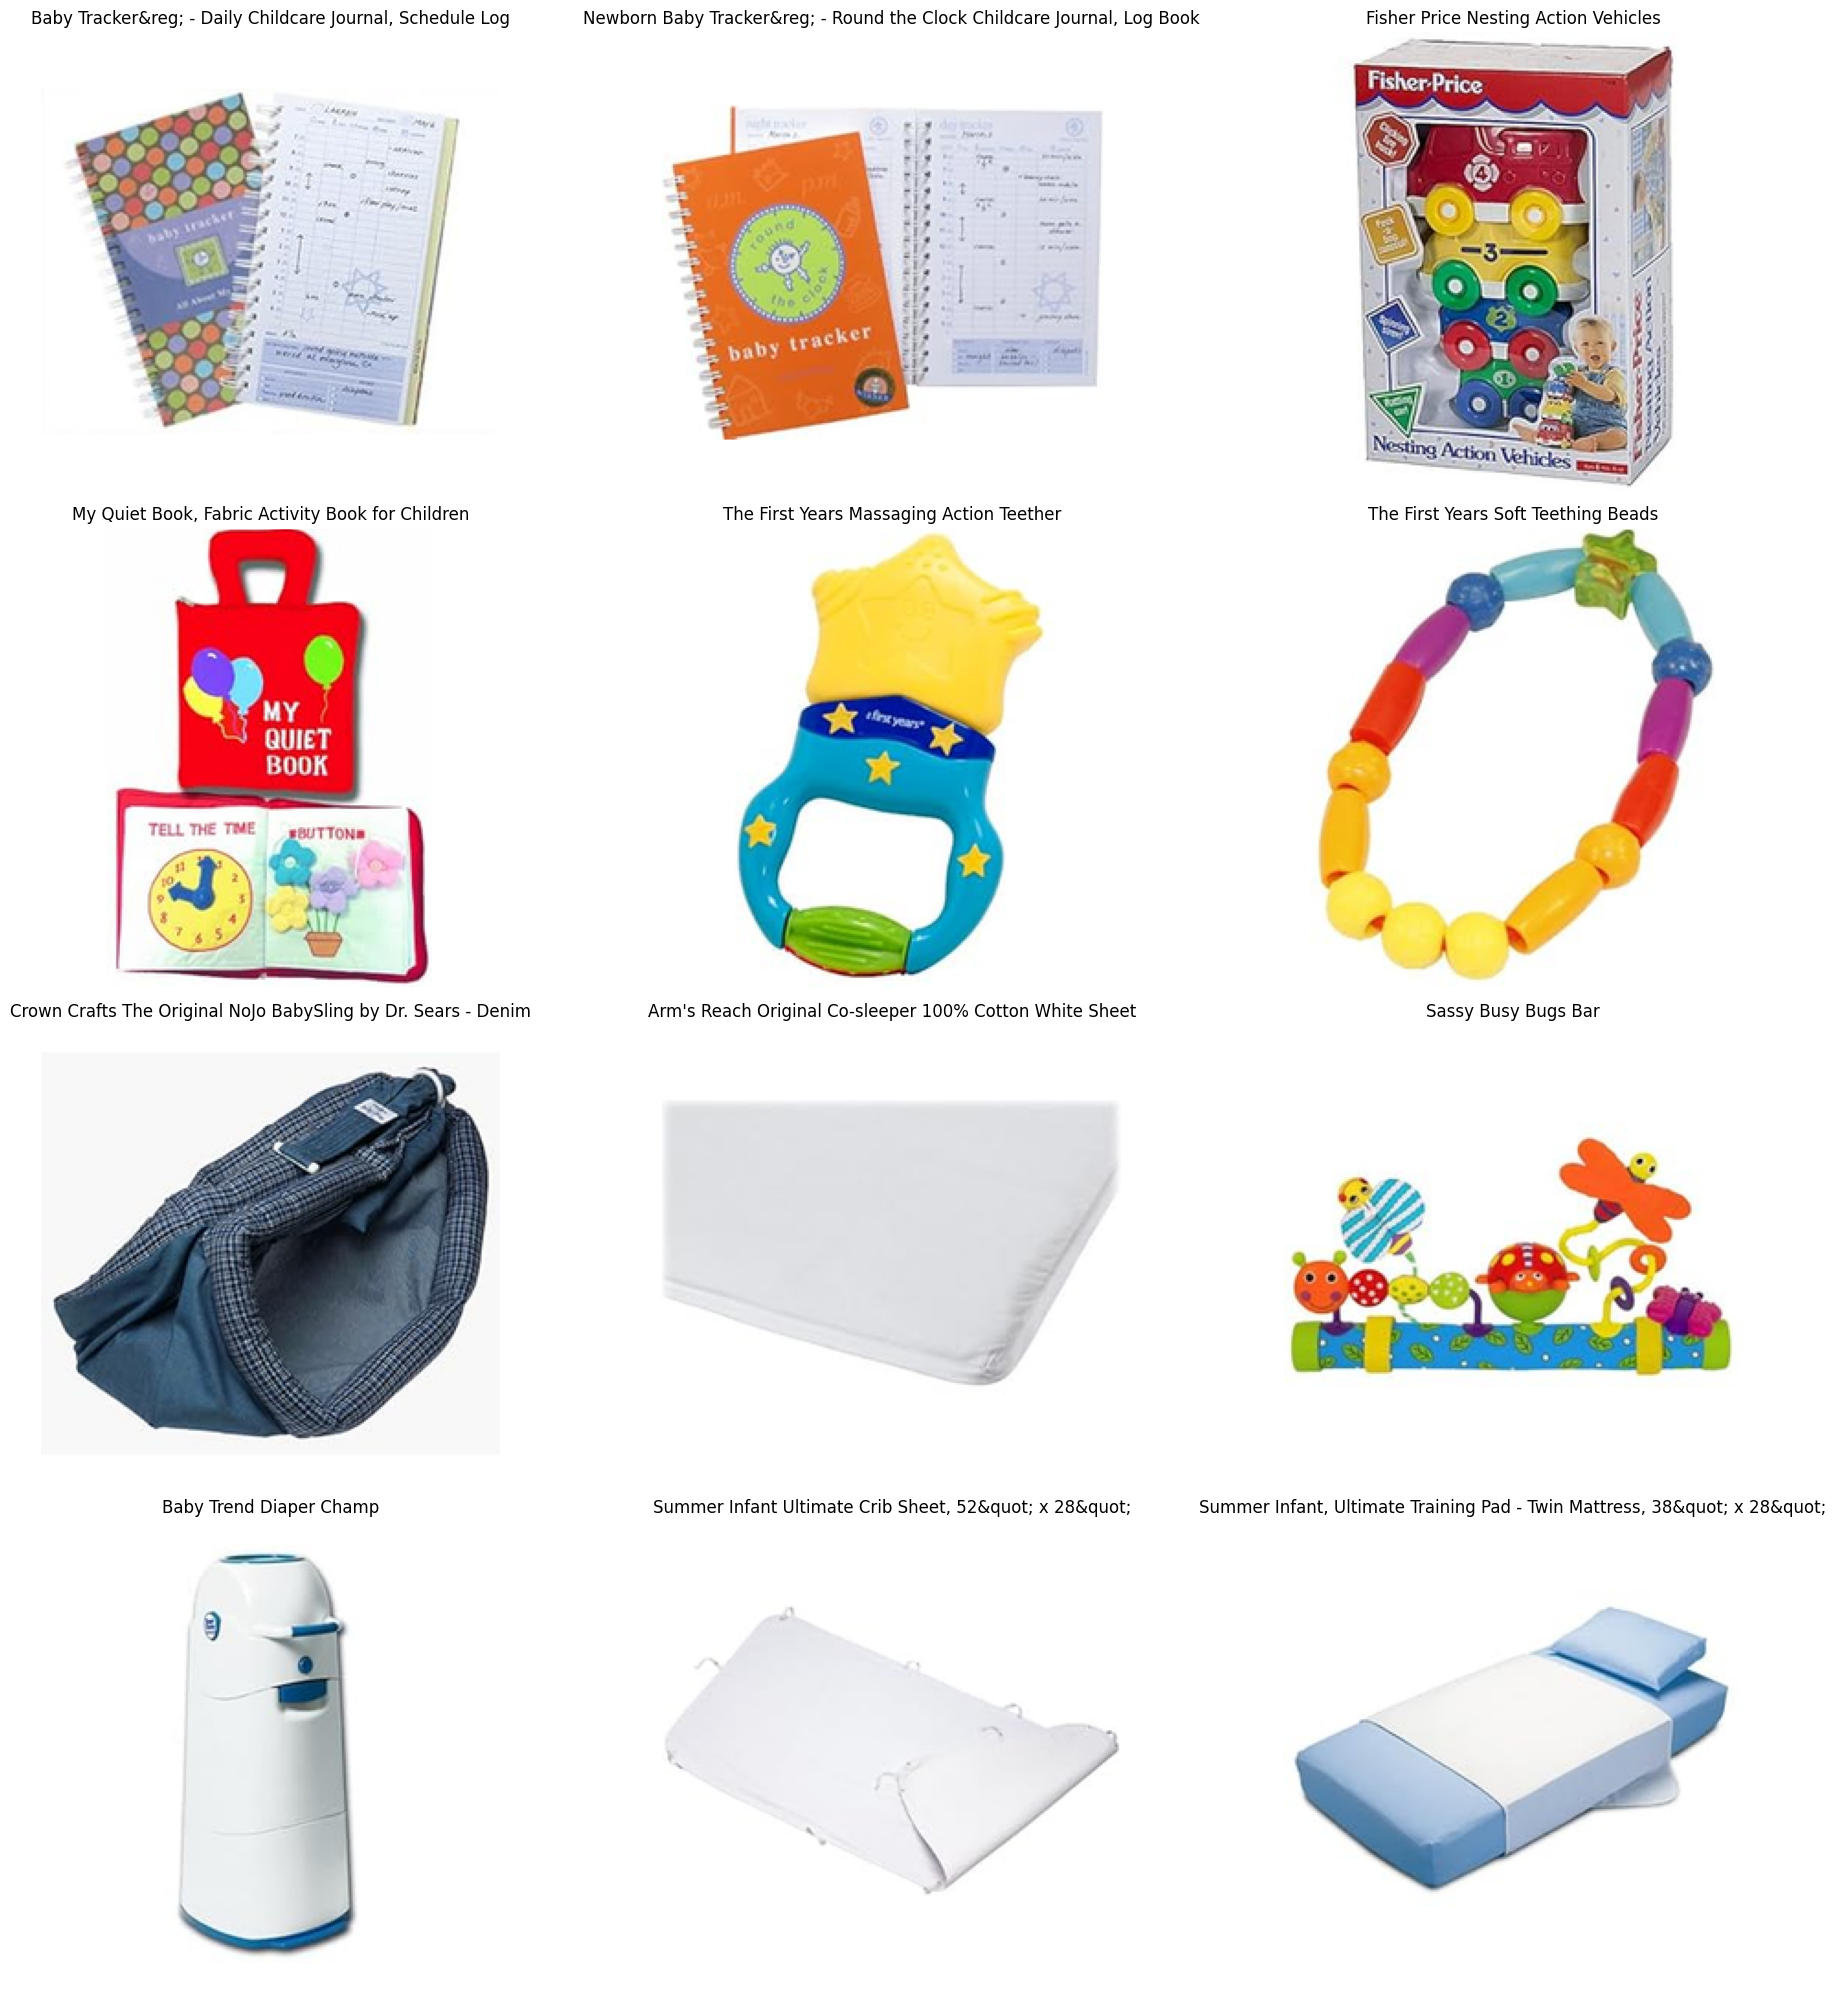

In [13]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image as PILImage

# Get the first 12 rows from df_meta for a 4x3 grid
first_10_meta = df_meta.head(12)

# Construct the base directory for images
images_base_dir = Path(f"{PATH}/step4_image_feature_extract/filtered_images/downloaded_images")

print(f"Displaying images for the first 12 items from df_meta in a 4x3 grid:")

# Set up the figure and subplots for a 4x3 grid
fig, axes = plt.subplots(4, 3, figsize=(20, 20)) # Increased figure size to 20x20
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Define a target size for each image within its cell for consistency
target_image_size = (250, 250) # pixels, for a square image in each cell, slightly larger

for i, (index, row) in enumerate(first_10_meta.iterrows()):
    asin = row['asin']
    title = row['title'] if pd.notna(row['title']) else asin # Use ASIN if title is missing

    img_path = images_base_dir / f"{asin}.jpg"

    ax = axes[i] # Get the current axis

    if img_path.is_file():
        try:
            original_pil_img = PILImage.open(img_path)
            # Create a white background canvas of target_image_size
            canvas_img = PILImage.new('RGB', target_image_size, color = 'white')

            # Resize the original image to fit within the target size while maintaining aspect ratio
            original_pil_img.thumbnail(target_image_size, PILImage.Resampling.LANCZOS)

            # Calculate paste position to center the image on the canvas
            paste_x = (target_image_size[0] - original_pil_img.width) // 2
            paste_y = (target_image_size[1] - original_pil_img.height) // 2

            canvas_img.paste(original_pil_img, (paste_x, paste_y))

            ax.imshow(canvas_img) # Display the standardized canvas image
            ax.set_title(title, fontsize=12) # Increased fontsize to 12
            ax.axis('off') # Hide axes ticks and labels
        except Exception as e:
            print(f"Could not load image {img_path.name} with PIL: {e}")
            ax.text(0.5, 0.5, 'Error', ha='center', va='center', transform=ax.transAxes, fontsize=12, color='red') # Increased fontsize to 12
            ax.set_title(title, fontsize=12)
            ax.axis('off')
    else:
        print(f"Image file not found for ASIN: {asin} at {img_path}")
        ax.text(0.5, 0.5, 'No Image', ha='center', va='center', transform=ax.transAxes, fontsize=12, color='gray') # Increased fontsize to 12
        ax.set_title(title, fontsize=12)
        ax.axis('off')

# Hide any unused subplots if less than 12 images were processed
for j in range(len(first_10_meta), 12):
    axes[j].axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

#### TÍNH CÁC CHỈ SỐ THỐNG KÊ TỔNG QUAN (KPIs)

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# =========================================================
# 1. TÍNH CÁC CHỈ SỐ THỐNG KÊ TỔNG QUAN (KPIs)
# =========================================================
n_users = df_ratings['userID'].nunique()
n_active_items = df_ratings['itemID'].nunique()
n_total_items = df_meta['asin'].nunique()
n_interactions = len(df_ratings)

# Tính độ thưa (Sparsity) và độ phủ (Coverage)
sparsity = (1 - (n_interactions / (n_users * n_active_items))) * 100
item_coverage = (n_active_items / n_total_items) * 100

# Lượt tương tác per User / Item
user_activity = df_ratings.groupby('userID').size()
item_popularity = df_ratings.groupby('itemID').size()

print('=== BÁO CÁO THỐNG KÊ TỔNG QUAN ===')
print(f'• Tổng số Người dùng (Users): {n_users:,}')
print(
    f'• Tổng số SP có tương tác / mua: {n_active_items:,} / {n_total_items:,}'
    f' ({item_coverage:.2f}% tổng kho)'
)
print(f'• Tổng số lượt tương tác/mua: {n_interactions:,}')
print(f'• Độ thưa ma trận tương tác (Sparsity): {sparsity:.4f}%')
print(
    f'• Lượt mua trung bình/User: {user_activity.mean():.2f} (Trung vị:'
    f' {user_activity.median():.0f})'
)
print(
    f'• Lượt mua trung bình/Item: {item_popularity.mean():.2f} (Trung vị:'
    f' {item_popularity.median():.0f})'
)

=== BÁO CÁO THỐNG KÊ TỔNG QUAN ===
• Tổng số Người dùng (Users): 19,445
• Tổng số SP có tương tác / mua: 7,050 / 7,050 (100.00% tổng kho)
• Tổng số lượt tương tác/mua: 160,792
• Độ thưa ma trận tương tác (Sparsity): 99.8827%
• Lượt mua trung bình/User: 8.27 (Trung vị: 6)
• Lượt mua trung bình/Item: 22.81 (Trung vị: 11)


#### Vẽ biểu đồ dữ liệu

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==============================================================================
# BƯỚC CHUẨN BỊ DỮ LIỆU & TÍNH TOÁN
# ==============================================================================
# 1. Tính toán số lượt tương tác từ df_ratings
user_activity = df_ratings.groupby('userID').size()
item_popularity = df_ratings.groupby('itemID').size()

# 2. Tính các chỉ số thống kê cho User
u_q25, u_q50, u_q75 = np.percentile(user_activity, [25, 50, 75])
u_mean = user_activity.mean()

# 3. Tính các chỉ số thống kê cho Item
i_q25, i_q50, i_q75 = np.percentile(item_popularity, [25, 50, 75])
i_mean = item_popularity.mean()

# 4. Cấu hình giao diện chung
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 11

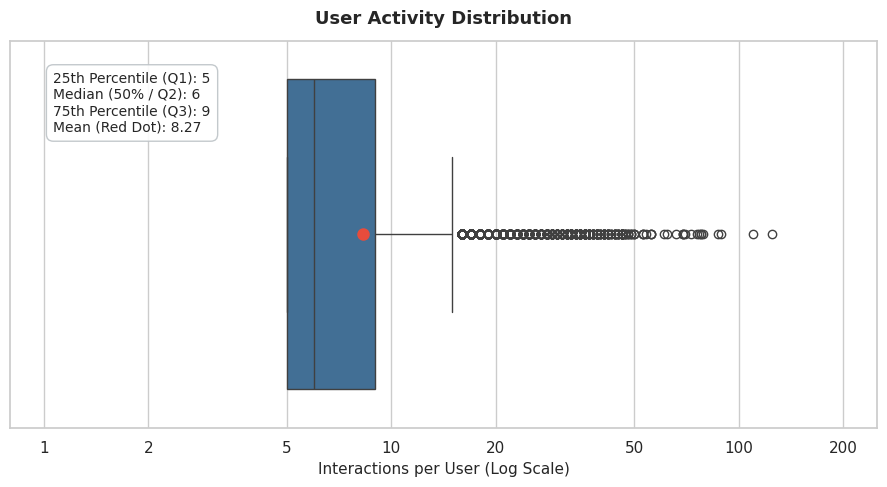

In [22]:
plt.figure(figsize=(9, 5))

ax = sns.boxplot(
    x=user_activity,
    color='#3470a3',
    showmeans=True,
    meanprops={
        'marker': 'o',
        'markerfacecolor': '#e74c3c',
        'markeredgecolor': '#e74c3c',
        'markersize': 8,
    },
)

plt.title('User Activity Distribution', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Interactions per User (Log Scale)', fontsize=11)
plt.xscale('log')

# ==============================================================================
# BỔ SUNG / CẢI THIỆN TRỤC HOÀNH (X-AXIS) TẠI ĐÂY
# ==============================================================================
# 1. Định nghĩa các mốc hiển thị rõ ràng
custom_ticks = [1, 2, 5, 10, 20, 50, 100, 200]
plt.xticks(custom_ticks, [str(t) for t in custom_ticks])

# 2. Chỉnh giới hạn trục hoành để hình hộp không dính sát lề trái
plt.xlim(0.8, 250)
# ==============================================================================

# Khung chú thích
u_box_text = (
    f'25th Percentile (Q1): {u_q25:.0f}\n'
    f'Median (50% / Q2): {u_q50:.0f}\n'
    f'75th Percentile (Q3): {u_q75:.0f}\n'
    f'Mean (Red Dot): {u_mean:.2f}'
)
plt.text(
    0.05,
    0.92,
    u_box_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.9,
        edgecolor='#bdc3c7',
    ),
)

plt.tight_layout()
plt.savefig('user_activity_improved.png', dpi=300)
plt.show()

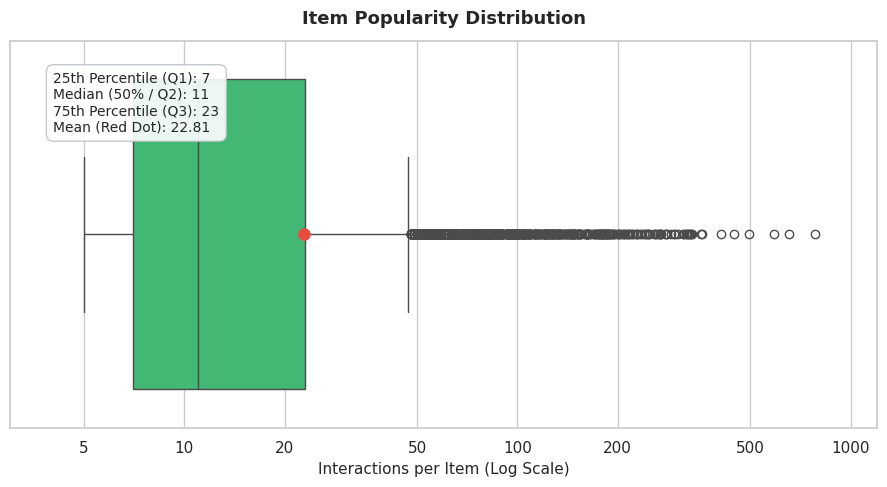

In [25]:
plt.figure(figsize=(9, 5))

ax2 = sns.boxplot(
    x=item_popularity,
    color='#2ecc71',
    showmeans=True,
    meanprops={
        'marker': 'o',
        'markerfacecolor': '#e74c3c',
        'markeredgecolor': '#e74c3c',
        'markersize': 8,
    },
)

plt.title(
    'Item Popularity Distribution', fontsize=13, fontweight='bold', pad=12
)
plt.xlabel('Interactions per Item (Log Scale)', fontsize=11)
plt.xscale('log')

# ==============================================================================
# BỔ SUNG TRỤC HOÀNH RÕ RÀNG HƠN
# ==============================================================================
custom_ticks = [5, 10, 20, 50, 100, 200, 500, 1000]
plt.xticks(custom_ticks, [str(t) for t in custom_ticks])
plt.xlim(3, 1200)  # Nới lề hai bên cho hình cân đối
# ==============================================================================

# Khung chú thích
i_box_text = (
    f'25th Percentile (Q1): {i_q25:.0f}\n'
    f'Median (50% / Q2): {i_q50:.0f}\n'
    f'75th Percentile (Q3): {i_q75:.0f}\n'
    f'Mean (Red Dot): {i_mean:.2f}'
)
plt.text(
    0.05,
    0.92,
    i_box_text,
    transform=ax2.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.9,
        edgecolor='#bdc3c7',
    ),
)

plt.tight_layout()
plt.savefig('item_popularity_distribution_improved.png', dpi=300)
plt.show()

/tmp/ipykernel_845/2249787837.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


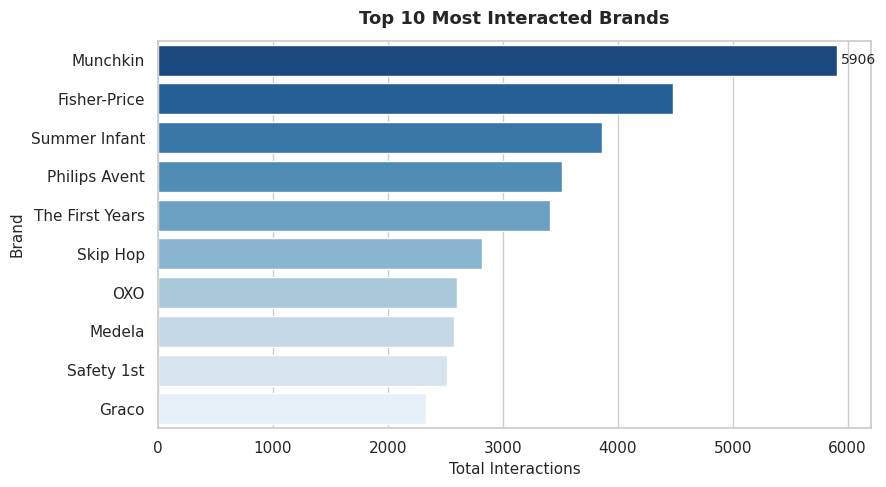

/tmp/ipykernel_845/2249787837.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


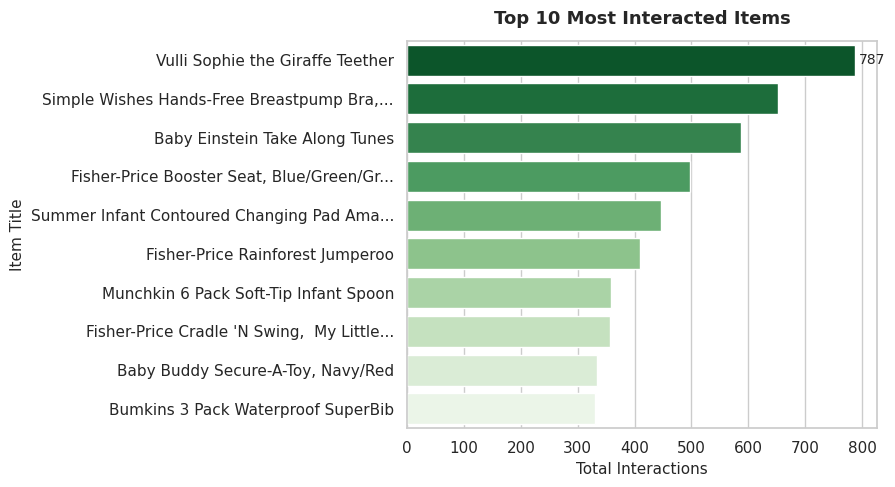

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Cấu hình giao diện chung
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 11

# Ghép bảng dữ liệu rating với metadata
df_merged = df_ratings.merge(df_meta, left_on='itemID', right_on='asin')

# ==============================================================================
# 1. BIỂU ĐỒ TOP 10 THƯƠNG HIỆU (TOP 10 BRANDS)
# ==============================================================================
top_brands = (
    df_merged.groupby('brand')
    .size()
    .reset_index(name='interactions')
    .sort_values('interactions', ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
ax1 = sns.barplot(
    data=top_brands,
    y='brand',
    x='interactions',
    palette='Blues_r',
)

# Hiển thị con số chính xác ở đầu mỗi thanh
ax1.bar_label(ax1.containers[0], padding=3, fmt='%d', fontsize=10)

plt.title(
    'Top 10 Most Interacted Brands',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Total Interactions', fontsize=11)
plt.ylabel('Brand', fontsize=11)

plt.tight_layout()
plt.savefig('top_10_brands.png', dpi=300)
plt.show()


# ==============================================================================
# 2. BIỂU ĐỒ TOP 10 SẢN PHẨM (TOP 10 ITEMS)
# ==============================================================================
# Lấy tên sản phẩm (title/name), nếu không có tên thì lấy mã 'itemID'
title_col = (
    'title'
    if 'title' in df_merged.columns
    else ('title_x' if 'title_x' in df_merged.columns else 'itemID')
)

top_items = (
    df_merged.groupby([title_col])
    .size()
    .reset_index(name='interactions')
    .sort_values('interactions', ascending=False)
    .head(10)
)

# Cắt ngắn tên sản phẩm nếu quá dài (> 40 ký tự) để tránh đè chữ
top_items['short_title'] = top_items[title_col].apply(
    lambda x: str(x)[:40] + '...' if len(str(x)) > 40 else str(x)
)

plt.figure(figsize=(9, 5))
ax2 = sns.barplot(
    data=top_items,
    y='short_title',
    x='interactions',
    palette='Greens_r',
)

# Hiển thị con số chính xác ở đầu mỗi thanh
ax2.bar_label(ax2.containers[0], padding=3, fmt='%d', fontsize=10)

plt.title(
    'Top 10 Most Interacted Items',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Total Interactions', fontsize=11)
plt.ylabel('Item Title', fontsize=11)

plt.tight_layout()
plt.savefig('top_10_items.png', dpi=300)
plt.show()

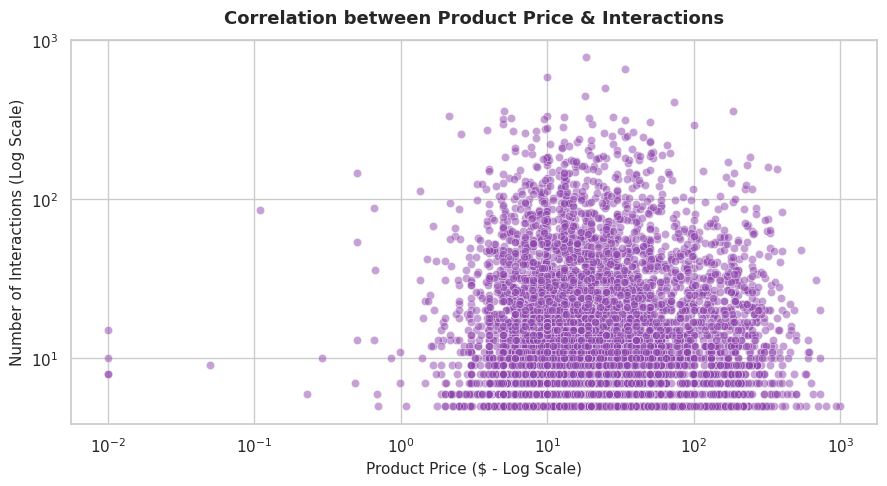

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 11

# Ghép bảng dữ liệu
item_stats = (
    df_ratings.groupby('itemID')
    .size()
    .reset_index(name='buy_count')
    .merge(df_meta, left_on='itemID', right_on='asin')
)

plt.figure(figsize=(9, 5))

# Scatter plot với độ trong suốt (alpha) để xử lý đè điểm dữ liệu
ax = sns.scatterplot(
    data=item_stats.dropna(subset=['price']),
    x='price',
    y='buy_count',
    alpha=0.5,
    color='#8e44ad',
    s=35,
)

plt.title(
    'Correlation between Product Price & Interactions',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Product Price ($ - Log Scale)', fontsize=11)
plt.ylabel('Number of Interactions (Log Scale)', fontsize=11)

# Áp dụng Log scale giúp phân bố điểm dữ liệu rõ ràng hơn
plt.xscale('log')
plt.yscale('log')

plt.tight_layout()
plt.savefig('price_vs_interactions.png', dpi=300)
plt.show()

In [37]:
# # =========================================================
# # 2. VẼ CÁC BIỂU ĐỒ TRỰC QUAN HÓA
# # =========================================================
# sns.set_theme(style='whitegrid')
# fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# # --- Biểu đồ 1: Quy luật đuôi dài (Long-tail Item Popularity) ---
# item_counts_sorted = item_popularity.sort_values(ascending=False).values
# axes[0, 0].plot(item_counts_sorted, color='crimson', linewidth=2)
# axes[0, 0].set_yscale('log')  # Thang log để thấy rõ đuôi dài
# axes[0, 0].set_title('1. Phân bố Độ phổ biến Sản phẩm (Quy luật Long-tail)')
# axes[0, 0].set_xlabel('Thứ hạng Sản phẩm (Xếp theo lượt mua)')
# axes[0, 0].set_ylabel('Số lượt mua (Thang Log)')

# # --- Biểu đồ 2: Phân bố mức độ hoạt động của User ---
# sns.histplot(ax=axes[0, 1], data=user_activity, bins=30, kde=True, color='teal')
# axes[0, 1].set_title('2. Mức độ Hoạt động của Người dùng (Interactions/User)')
# axes[0, 1].set_xlabel('Số lượng sản phẩm User đã mua/tương tác')
# axes[0, 1].set_ylabel('Số lượng User')

# # --- Biểu đồ 3: Top Thương hiệu được mua nhiều nhất ---
# df_merged = df_ratings.merge(df_meta, left_on='itemID', right_on='asin')
# top_brands = (
#     df_merged.groupby('brand')
#     .size()
#     .reset_index(name='interactions')
#     .sort_values('interactions', ascending=False)
#     .head(10)
# )

# sns.barplot(
#     ax=axes[1, 0],
#     data=top_brands,
#     y='brand',
#     x='interactions',
#     palette='Blues_r',
# )
# axes[1, 0].set_title('3. Top 10 Thương hiệu có nhiều Lượt mua/Tương tác nhất')
# axes[1, 0].set_xlabel('Tổng số lượt tương tác')
# axes[1, 0].set_ylabel('Thương hiệu')

# # --- Biểu đồ 4: Mối tương quan giữa Giá tiền & Số lượt mua ---
# item_stats = (
#     df_ratings.groupby('itemID')
#     .size()
#     .reset_index(name='buy_count')
#     .merge(df_meta, left_on='itemID', right_on='asin')
# )

# sns.scatterplot(
#     ax=axes[1, 1],
#     data=item_stats.dropna(subset=['price']),
#     x='price',
#     y='buy_count',
#     alpha=0.6,
#     color='purple',
# )
# axes[1, 1].set_title('4. Tương quan giữa Giá sản phẩm & Số lượt mua')
# axes[1, 1].set_xlabel('Giá sản phẩm ($)')
# axes[1, 1].set_ylabel('Số lượt mua')

# plt.tight_layout()
# plt.show()